In [9]:
import codecs
import os

In [10]:
from sklearn.decomposition import LatentDirichletAllocation

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

In [12]:
PATH = 'Zhitiya_raw'
NUM_TOPICS = 4
N_FIRST = 10 # сколько первых слов на тему выводить
MIN_DF = 4 # минимальное число вхождений слова в документ, чтобы мы его учитывали (включали в вектор документа)
MAX_DF = 0.90 # в каком проценте документов должно присутствовать слово, чтобы оно не рассматривалось
STW_PATH = 'stopwords-ru.txt' # путь к стоп-словам. Я удалила включила сюда имена святых

In [ ]:
with codecs.open(STW_PATH, encoding = 'utf-8') as f:
    stw_list = f.read().split()[1:]

In [14]:
import pymorphy2
import re

morph = pymorphy2.MorphAnalyzer()

def lemmatize_text(text):
    words = re.findall(r'\b[а-яА-ЯёЁ]+\b', text.lower())
    lemmas = [morph.parse(word)[0].normal_form for word in words if word not in stw_list]
    return ' '.join(lemmas)


In [15]:
file_names = os.listdir(PATH)
data = []
for name in file_names:
    if name.endswith(".txt"):
        with codecs.open(PATH + "/" + name, encoding='utf-8') as f:
            text = f.read()
            lemmatized_text = lemmatize_text(text)
            data.append(lemmatized_text)
print(data[:10])

['житие преподобный отец наш афанасий архиепископ александрийский память праздноваться месяц январь й день святой афанасий великий сей живой бессмертный образ добродетель богоугодный жизнь родиться знаменитый столица египет александрия родитель христианин человек благочестивый добродетельный день отрочество афанасий следующий предзнаменовать будущий великий святительский деятельность однажды афанасий играть свой сверстник морской берег ребёнок подражать видеть церковь изображать игра священнослужитель божий церковный обряд афанасий избрать епископ наименовать один пресвитер другой диакон последний приводить другой ребёнок языческий крестить афанасий крестить морской вода произносить установленный таинство святой крещение слово слышать священник церковь присоединять поучение сообразно свой детский возраст время патриарх александрийский святой александр случайно взглянуть окно дом находиться возвышенный место недалеко море берег море увидеть детский игра изумление следить совершать афана

In [16]:
count_vectorizer = CountVectorizer(min_df=MIN_DF, max_df=MAX_DF, stop_words = stw_list)
data_count_vectorized = count_vectorizer.fit_transform(data)

In [17]:
lda_model = LatentDirichletAllocation(n_components=NUM_TOPICS, max_iter=50, learning_method='batch', batch_size=512, random_state = 2)
lda_model.fit_transform(data_count_vectorized);

In [18]:
# print function
all_topics = []
def print_topics(model, vectorizer, top_n=N_FIRST):
    for idx, topic in enumerate(model.components_):
        print("Topic %d:" % (idx))
        all_topics.append([(vectorizer.get_feature_names_out()[i], topic[i])
                        for i in topic.argsort()[:-top_n - 1:-1]])
        print([(vectorizer.get_feature_names_out()[i], topic[i])
                        for i in topic.argsort()[:-top_n - 1:-1]])

In [19]:
print_topics(lda_model, count_vectorizer)

Topic 0:
[('царь', 343.46372241655644), ('афанасий', 154.5193771102648), ('царица', 123.98567434302828), ('престол', 115.02453422114974), ('божий', 113.1841160918811), ('город', 107.6595636365885), ('патриарх', 104.86304567266758), ('феодора', 104.22394109874428), ('народ', 103.50495583854587), ('против', 93.65090020665978)]
Topic 1:
[('преподобный', 845.8295644400808), ('прийти', 196.85038202475192), ('брат', 170.31591682512666), ('инок', 167.76790372613505), ('монастырь', 152.82084604609958), ('старец', 145.64891610485674), ('братия', 137.22754515635086), ('лавр', 135.24249093370923), ('пустыня', 135.15153360567288), ('божий', 131.21383201253866)]
Topic 2:
[('божий', 126.35204828584905), ('господь', 99.98555659122727), ('город', 97.70774261594397), ('народ', 96.97610848828803), ('царь', 94.54359189675878), ('отвечать', 92.32018841962673), ('сын', 79.08623885072507), ('рука', 74.30179344600533), ('всякий', 71.56542377993617), ('христианин', 70.07738650214066)]
Topic 3:
[('собор', 13.2

In [20]:
for i,topic in enumerate(all_topics):
    print("-------------------------------")
    print("Тема ",i)
    for pair in topic:
        print(pair[0])

-------------------------------
Тема  0
царь
афанасий
царица
престол
божий
город
патриарх
феодора
народ
против
-------------------------------
Тема  1
преподобный
прийти
брат
инок
монастырь
старец
братия
лавр
пустыня
божий
-------------------------------
Тема  2
божий
господь
город
народ
царь
отвечать
сын
рука
всякий
христианин
-------------------------------
Тема  3
собор
богослов
мудрость
божественный
константинополь
вскоре
святитель
друг
занятие
писание


In [ ]:
! pip install pyLDAvis


In [22]:
# визуализация
import pyLDAvis.lda_model
pyLDAvis.enable_notebook()
panel = pyLDAvis.lda_model.prepare

#import sklearn.pyLDAvis

panel

<function pyLDAvis.lda_model.prepare(lda_model, dtm, vectorizer, **kwargs)>

In [23]:
lda_model.perplexity(data_count_vectorized)

1478.2883316748098

In [24]:
! pip install gensim


Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 24.2 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:


from gensim.models import CoherenceModel
from gensim import corpora

# Преобразуем данные в формат gensim (словарь и корпус)
data_gensim = [text.split() for text in data]

# Создаем словарь для gensim
dictionary = corpora.Dictionary(data_gensim)

# Преобразуем данные в формат мешка слов (bag-of-words)
corpus = [dictionary.doc2bow(text) for text in data_gensim]

topics = []
for topic in lda_model.components_:
    top_words = topic.argsort()[-10:][::-1]  # Получаем топ-10 слов для каждой темы
    topics.append([dictionary[i] for i in top_words])

coherence_model_lda = CoherenceModel(topics=topics, texts=data_gensim, dictionary=dictionary, coherence='u_mass')

coherence_lda = coherence_model_lda.get_coherence()
print(f'U-Mass Coherence: {coherence_lda}')

U-Mass Coherence: -4.081547566519013


In [26]:
import matplotlib.pyplot as plt
import gensim
from gensim.models import CoherenceModel
from gensim import corpora

def compute_coherence_values(dictionary, corpus, texts, limit, start=2, step=3):
    coherence_values = []
    model_list = []
    for num_topics in range(start, limit, step):
        # Обучаем модель LDA с gensim
        model = gensim.models.ldamodel.LdaModel(corpus=corpus, id2word=dictionary, num_topics=num_topics)
        model_list.append(model)
        
        # Вычисляем когерентность для этой модели
        coherencemodel = CoherenceModel(model=model, texts=texts, dictionary=dictionary, coherence='c_v')
        coherence_values.append(coherencemodel.get_coherence())

    return model_list, coherence_values



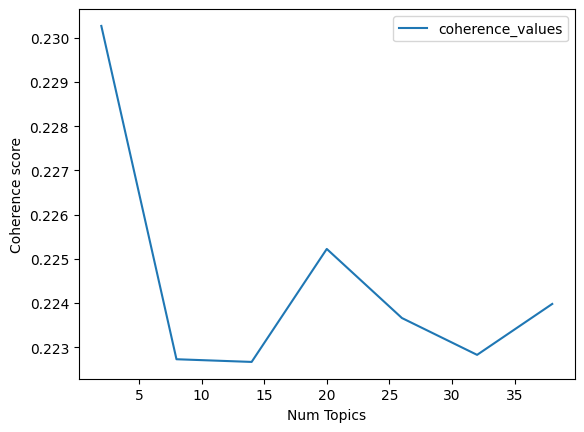

In [27]:
# Преобразуем данные в список слов
data_gensim = [text.split() for text in data]

# Создаем словарь gensim
dictionary = corpora.Dictionary(data_gensim)

# Преобразуем данные в формат мешка слов (bag-of-words)
corpus = [dictionary.doc2bow(text) for text in data_gensim]

# Вызов функции для вычисления когерентности
start, limit, step = 2, 40, 6
model_list, coherence_values = compute_coherence_values(dictionary=dictionary, corpus=corpus, texts=data_gensim, start=start, limit=limit, step=step)

# Построение графика
x = range(start, limit, step)
plt.plot(x, coherence_values)
plt.xlabel("Num Topics")
plt.ylabel("Coherence score")
plt.legend(["coherence_values"], loc='best')
plt.show()

BERTopic

In [ ]:
! pip install bertopic

In [32]:
from hdbscan import HDBSCAN
hdbscan_model = HDBSCAN(min_cluster_size=2, metric='euclidean', prediction_data=True)

In [33]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from sklearn.pipeline import make_pipeline

# Настройка параметров векторизации
vectorizer_model = CountVectorizer(
    min_df = 1,
    max_df = 19,
    stop_words=stw_list
)

# Настройка модели уменьшения размерности
umap_model = UMAP(n_neighbors=5, n_components=15, min_dist=0.0, metric='cosine', random_state=42)

# Создание и обучение модели BERTopic
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    nr_topics=NUM_TOPICS,
    top_n_words=N_FIRST,
    language="multilingual",  # Учитывая, что тексты на русском
    verbose=True
)

# Обучение модели на ваших лемматизированных данных
topics, probs = topic_model.fit_transform(data)

# Выводим топики
topic_model.get_topic_info()


2025-05-06 18:13:55,633 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 1/1 [00:01<00:00,  1.55s/it]
2025-05-06 18:14:01,388 - BERTopic - Embedding - Completed ✓
2025-05-06 18:14:01,388 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-06 18:14:01,433 - BERTopic - Dimensionality - Completed ✓
2025-05-06 18:14:01,435 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-06 18:14:01,437 - BERTopic - Cluster - Completed ✓
2025-05-06 18:14:01,437 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-05-06 18:14:01,742 - BERTopic - Representation - Completed ✓
2025-05-06 18:14:01,742 - BERTopic - Topic reduction - Reducing number of topics
2025-05-06 18:14:01,749 - BERTopic - Topic reduction - Number of topics (4) is equal or higher than the clustered topics(4).
2025-05-06 18:14:01,749 - BERTopic - Representation - Fine-tuning topics using representation models.
20

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2,-1_савва_преподобный_святой_лавр,"[савва, преподобный, святой, лавр, отец, патри...",[житие преподобный богоносный отец наш симеон ...
1,0,8,0_святой_преподобный_бог_время,"[святой, преподобный, бог, время, церковь, афа...",[житие преподобный отец наш феодосия великий п...
2,1,5,1_святой_феодора_царь_церковь,"[святой, феодора, царь, церковь, бог, отец, пр...",[житие святой отец наш григорий чудотворец епи...
3,2,5,2_святой_бог_преподобный_говорить,"[святой, бог, преподобный, говорить, отвечать,...",[житие преподобный отец наш антоний великий па...


bertopic без лемматизации

In [34]:
def clean_text(text):
    words = re.findall(r'\b[а-яА-ЯёЁ]+\b', text.lower())
    words = [w for w in words if w not in stw_list]
    return ' '.join(words)


In [35]:
file_names = os.listdir(PATH)
data = []
for name in file_names:
    if name.endswith(".txt"):
        with codecs.open(PATH + "/" + name, encoding='utf-8') as f:
            text = f.read()
            cleaned_text = lemmatize_text(text)
            data.append(cleaned_text)
print(data[:10])

['житие преподобный отец наш афанасий архиепископ александрийский память праздноваться месяц январь й день святой афанасий великий сей живой бессмертный образ добродетель богоугодный жизнь родиться знаменитый столица египет александрия родитель христианин человек благочестивый добродетельный день отрочество афанасий следующий предзнаменовать будущий великий святительский деятельность однажды афанасий играть свой сверстник морской берег ребёнок подражать видеть церковь изображать игра священнослужитель божий церковный обряд афанасий избрать епископ наименовать один пресвитер другой диакон последний приводить другой ребёнок языческий крестить афанасий крестить морской вода произносить установленный таинство святой крещение слово слышать священник церковь присоединять поучение сообразно свой детский возраст время патриарх александрийский святой александр случайно взглянуть окно дом находиться возвышенный место недалеко море берег море увидеть детский игра изумление следить совершать афана

In [ ]:
from bertopic import BERTopic
from sklearn.feature_extraction.text import CountVectorizer
from umap import UMAP
from sklearn.pipeline import make_pipeline

# Настройка параметров векторизации
vectorizer_model = CountVectorizer(
    min_df = 1,
    max_df = 19,
    stop_words=stw_list
)

# Настройка модели уменьшения размерности
umap_model = UMAP(n_neighbors=5, n_components=15, min_dist=0.0, metric='cosine', random_state=42)

# Создание и обучение модели BERTopic
topic_model = BERTopic(
    vectorizer_model=vectorizer_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    nr_topics=NUM_TOPICS,
    top_n_words=N_FIRST,
    language="multilingual",  # Учитывая, что тексты на русском
    verbose=True
)

# Обучение модели на ваших лемматизированных данных
topics, probs = topic_model.fit_transform(data)

# Выводим топики
topic_model.get_topic_info()


2025-05-06 18:18:11,612 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 1/1 [00:01<00:00,  1.46s/it]
2025-05-06 18:18:17,191 - BERTopic - Embedding - Completed ✓
2025-05-06 18:18:17,191 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-05-06 18:18:17,233 - BERTopic - Dimensionality - Completed ✓
2025-05-06 18:18:17,235 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-05-06 18:18:17,240 - BERTopic - Cluster - Completed ✓
2025-05-06 18:18:17,240 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2025-05-06 18:18:17,333 - BERTopic - Representation - Completed ✓
2025-05-06 18:18:17,333 - BERTopic - Topic reduction - Reducing number of topics
2025-05-06 18:18:17,333 - BERTopic - Topic reduction - Number of topics (4) is equal or higher than the clustered topics(4).
2025-05-06 18:18:17,333 - BERTopic - Representation - Fine-tuning topics using representation models.
20

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2,-1_савва_преподобный_святой_лавр,"[савва, преподобный, святой, лавр, отец, патри...",[житие преподобный богоносный отец наш симеон ...
1,0,8,0_святой_преподобный_бог_время,"[святой, преподобный, бог, время, церковь, афа...",[житие преподобный отец наш феодосия великий п...
2,1,5,1_святой_феодора_царь_церковь,"[святой, феодора, царь, церковь, бог, отец, пр...",[житие святой отец наш григорий чудотворец епи...
3,2,5,2_святой_бог_преподобный_говорить,"[святой, бог, преподобный, говорить, отвечать,...",[житие преподобный отец наш антоний великий па...


In [38]:
from gensim.corpora import Dictionary
from gensim.models.coherencemodel import CoherenceModel

# Токенизация документов (если вы уже не делали)
tokenized_docs = [doc.split() for doc in data]

# Создание словаря и корпуса
dictionary = Dictionary(tokenized_docs)
corpus = [dictionary.doc2bow(text) for text in tokenized_docs]

# Получаем темы из BERTopic
topics = topic_model.get_topics()
topic_words = [ [word for word, _ in topics[topic_id]] for topic_id in topic_model.get_topic_freq().Topic if topic_id != -1 ]

# Вычисляем когезию
coherence_model = CoherenceModel(
    topics=topic_words,
    texts=tokenized_docs,
    dictionary=dictionary,
    coherence='c_v'  # можно также: 'u_mass', 'c_uci', 'c_npmi'
)

coherence_score = coherence_model.get_coherence()
print(f"Coherence Score (C_v): {coherence_score:.4f}")

Coherence Score (C_v): 0.3169


BERTopic nr_topics=2 → C_v coherence=0.2955
BERTopic nr_topics=4 → C_v coherence=0.3324
BERTopic nr_topics=6 → C_v coherence=0.3324
BERTopic nr_topics=8 → C_v coherence=0.3324


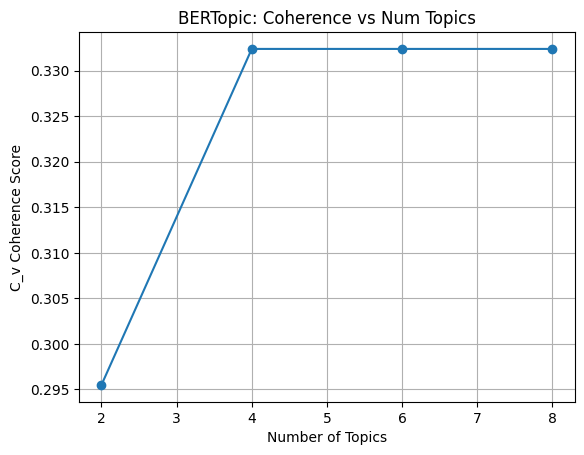

In [39]:
# Предварительная подготовка
tokenized_docs = [doc.split() for doc in data]
dictionary = corpora.Dictionary(tokenized_docs)
corpus = [dictionary.doc2bow(text) for text in tokenized_docs]

# Настройка моделей
vectorizer_model = CountVectorizer(stop_words=stw_list)
umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=2, metric='euclidean', prediction_data=True)

# Параметры перебора
start, limit, step = 2, 10, 2  # Можно изменить диапазон
nr_topics_list = range(start, limit, step)
coherence_scores = []

# Перебор моделей с разным числом тем
for n_topics in nr_topics_list:
    topic_model = BERTopic(
        nr_topics=n_topics,
        vectorizer_model=vectorizer_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        language="multilingual",
        verbose=False
    )

    topics, _ = topic_model.fit_transform(data)

    # Извлекаем слова из тем
    topics_words = topic_model.get_topics()
    topic_word_list = [
        [word for word, _ in topics_words[topic_id][:10]]
        for topic_id in topic_model.get_topic_freq().Topic
        if topic_id != -1
    ]

    # Считаем когерентность
    cm = CoherenceModel(
        topics=topic_word_list,
        texts=tokenized_docs,
        dictionary=dictionary,
        coherence='c_v'
    )
    coherence = cm.get_coherence()
    coherence_scores.append(coherence)
    print(f"BERTopic nr_topics={n_topics} → C_v coherence={coherence:.4f}")

# Визуализация
plt.plot(nr_topics_list, coherence_scores, marker='o')
plt.xlabel("Number of Topics")
plt.ylabel("C_v Coherence Score")
plt.title("BERTopic: Coherence vs Num Topics")
plt.grid(True)
plt.show()